## Important AI notice: 

To be completely transparent, I've been running low on time with this lab. It's 11:50pm and I'm about to submit it. As per usual, I used AI in situations where I understood the code and chose to save myself time. 

However, I had to use AI entirely for part 2: 3a, 3b, and 3c. I prioritized getting the code out of the way so I could have time to interpret the output. I plan on looking back at the code to understand it better.

I've been sick for a couple days, and I couldn't be as proactive with my work as I would've liked to be. I apologize for this. If you'd like to take off partial/full credit for part 2.3, I won't question it.

I would've asked for an extension, but the MSDS program doesn't give breaks and the work would've piled up with the Understanding Uncertainty work due Wednesday.

Best,
Aaron

In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

In [18]:
peng = pd.read_csv('C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\penguins.csv').dropna(
    subset=["flipper_length_mm", "body_mass_g", "bill_length_mm", "bill_depth_mm", 'sex']
).reset_index(drop=True)

peng.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,female,2007
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,male,2007
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,male,2007


In [3]:
bike = pd.read_csv("C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\bike-sharing-daily.csv", parse_dates=["dteday"])
bike.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [4]:
#1.1
additive = smf.ols("body_mass_g ~ flipper_length_mm + C(sex) + C(species)", data=peng).fit()
print(additive.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     534.0
Date:                Tue, 29 Sep 2026   Prob (F-statistic):          3.37e-142
Time:                        16:01:31   Log-Likelihood:                -2364.4
No. Observations:                 333   AIC:                             4739.
Df Residuals:                     328   BIC:                             4758.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                -

## 1.1

The reference level for sex is female and the reference level for species is Adelie. The coef 836.26 for Gentoo penguins means that Gentoo penguins are automatically predicted to have an extra 836.26g of body mass based off of their species alone.

In [33]:
#1.2a
y = peng['body_mass_g']
Init = peng[['flipper_length_mm', 'sex', 'species']]
X = pd.get_dummies(Init, columns = ['sex', 'species'], drop_first=True, dtype=int)
reg = LinearRegression().fit(X, y)
predict = reg.predict(X)

print(reg.intercept_)
print(reg.coef_)
print(reg.score(X, y))

-365.81744976158734
[ 20.02491543 530.38109449 -87.63447792 836.26000815]
0.866888356233088


## 1.2

- (a) The values do all match!

- (b) If we wanted a confidence interval, the best methods would be to bootstrap our samples or to compute them manually. This would be done by resampling a large number of times, refitting, and making our percentiles.

In [29]:
#1.3a
y = peng['body_mass_g']
Init = peng[['flipper_length_mm', 'sex', 'species']]
Xhot = pd.get_dummies(Init, columns = ['sex', 'species'], dtype=int)
reghot = LinearRegression().fit(Xhot, y)

print(Xhot.columns)

Index(['flipper_length_mm', 'sex_female', 'sex_male', 'species_Adelie',
       'species_Chinstrap', 'species_Gentoo'],
      dtype='str')


In [37]:
#1.3b
y = peng['body_mass_g']
Init = peng[['flipper_length_mm', 'sex', 'species']]
Xint = pd.get_dummies(Init, columns = ['sex', 'species'], dtype=int)
regint = LinearRegression(fit_intercept=True).fit(Xint, y)
predint = regint.predict(Xint)

print(np.max(np.abs(predict - predint)))
print(regint.score(Xint, y))
print(regint.coef_)

8.185452315956354e-12
0.866888356233088
[  20.02491543 -265.19054724  265.19054724 -249.54184341 -337.17632133
  586.71816474]


In [41]:
print(265.19054724 - (-265.19054724))
print(-249.54184341 - (-337.17632133))
print(586.71816474 - (-337.17632133))

530.38109448
87.63447792
923.8944860700001


## 1.3

- (a) I have 2 sex columns and 3 species columns.

- (b) R^2 and the predicted values here are nearly identical between the two models. 

- (c) I'm noticing that the coef differences are identical to the coefficients seen in the 1.2 model.

- (d) You need to be careful with encoding because of what you may be interpreting. As seen by the coefficient difference between male and female, you may be accounting for only half or possibly double the difference than you intend to if you use the wrong encoding.

In [ ]:
#1.4a. AI: I had generative ai help me with this step to speed up the coding process.
#I understand how the AI worked through the transformer and the pipeline.
preprocessor = ColumnTransformer(
    [('Categories', OneHotEncoder(drop='first'), ['sex', 'species']),
     ('num', 'passthrough', ['flipper_length_mm'])
     ]
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_raw = peng[['flipper_length_mm', 'sex', 'species']]
y = peng['body_mass_g']

feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
print("Feature Names:", feature_names)

coefs = model_pipeline.named_steps['regressor'].coef_
for name, coef in zip(feature_names, coefs):
    print(f"{name}: {coef:.4f}")

print("Intercept:", model_pipeline.named_steps['regressor'].intercept_)

Feature Names: ['Categories__sex_male' 'Categories__species_Chinstrap'
 'Categories__species_Gentoo' 'num__flipper_length_mm']
Categories__sex_male: 530.3811
Categories__species_Chinstrap: -87.6345
Categories__species_Gentoo: 836.2600
num__flipper_length_mm: 20.0249
Intercept: -365.8174497615464


In [54]:
#1.4b
new_penguin = pd.DataFrame({
    'flipper_length_mm': [215],
    'sex': ['male'],
    'species': ['Gentoo']
})

model_pipeline.predict(new_penguin)[0]

np.float64(5306.180470384637)

In [55]:
#2.1a
y = peng['body_mass_g']
X = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
model = LinearRegression().fit(X, y)
print(model.coef_)
print(model.score(X, y))

[50.76213167  3.29286254 17.83639105]
0.7639366781169292


In [56]:
#2.1b
y = peng['body_mass_g']
Xcm = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
Xcm['bill_length_cm'] = Xcm['bill_length_mm'] / 10
modelcent = LinearRegression().fit(Xcm, y)
print(modelcent.coef_)
print(modelcent.score(Xcm, y))

[50.76213167  3.26025994 17.83639105  0.32602599]
0.7639366781169292


## 2.1

- (a) Based on the values of each coefficient, recursive feature elimination would eliminate the bill_length predictor first.

- (b) While the R^2 and coefficients are unaffected, there's a new coefficient belonging to the new bill length predictor, which is far lower than the other three. With RFE, this new coef would surely be the first eliminated.

In [ ]:
#2.2a. AI: I simply couldn't figure out how to get the coefficient.
y = peng['body_mass_g']
X = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]

pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(X, y)

mode = pipe.named_steps['linearregression']
scale = pipe.named_steps['standardscaler']

print(mode.intercept_)
for col, coef in zip(X.columns, mode.coef_):
    print(f"{col}: {coef:.4f}")


4207.057057057057
flipper_length_mm: 710.4010
bill_length_mm: 8.9903
bill_depth_mm: 35.0713
bill_length_cm: 8.9903


In [ ]:
#2.2b
y = peng['body_mass_g']
Xcm = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
Xcm['bill_length_cm'] = Xcm['bill_length_mm'] / 10

pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(Xcm, y)

mode = pipe.named_steps['linearregression']
scale = pipe.named_steps['standardscaler']

print(mode.intercept_)
for col, coef in zip(Xcm.columns, mode.coef_):
    print(f"{col}: {coef:.4f}")

4207.057057057057
flipper_length_mm: 710.4010
bill_length_mm: 8.9903
bill_depth_mm: 35.0713
bill_length_cm: 8.9903


In [78]:
#2.2c
y = peng['body_mass_g']
X = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
minmaxpine = make_pipeline(MinMaxScaler(), LinearRegression())
robustpine = make_pipeline(RobustScaler(), LinearRegression())
minmaxpine.fit(X, y)
robustpine.fit(X, y)

mmode = minmaxpine.named_steps['linearregression']
rmode = robustpine.named_steps['linearregression']

print(mmode.intercept_)
print(rmode.intercept_)
for col, coef in zip(X.columns, mmode.coef_):
    print(f"{col}: {coef:.4f}")
for col, coef in zip(X.columns, rmode.coef_):
    print(f"{col}: {coef:.4f}")

2624.968214616864
4009.7658442707243
flipper_length_mm: 2994.9658
bill_length_mm: 90.5537
bill_depth_mm: 149.8257
flipper_length_mm: 1167.5290
bill_length_mm: 29.9650
bill_depth_mm: 55.2928


In [79]:
#2.2d
y = peng['body_mass_g']
X = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
Center = X - X.mean()
Model = LinearRegression().fit(Center, y)
print(Model.intercept_)
for col, coef in zip(Center.columns, Model.coef_):
    print(f"{col}: {coef:.4f}")

4207.057057057057
flipper_length_mm: 50.7621
bill_length_mm: 3.2929
bill_depth_mm: 17.8364


## 2.2

- (b) The unit conversion no longer matters with our new pipeline. The bill length predictor has the exact same coefficient for both millimeters and centimeters. 

- (c) The scalers don't seem to agree on specific values, but they do agree on the scale at which the values are related to each other. I believe standard scaler uses one deviation, minmax uses the full range, while robust uses the IQR as their units.

In [ ]:
#2.3
y = peng['body_mass_g']
X = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]

Xcm = peng[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
Xcm['bill_length_cm'] = Xcm['bill_length_mm'] / 10


Xcen = X - X.mean()

Xstd = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
Xmm = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=X.columns)

Models = {
    'Original': X,
    'Bill length cm': Xcm,
    'Centered': Xcen,
    'StandardScaler': Xstd,
    'MinMaxScaler': Xmm
}

{'Original':      flipper_length_mm  bill_length_mm  bill_depth_mm
 0                181.0            39.1           18.7
 1                186.0            39.5           17.4
 2                195.0            40.3           18.0
 3                193.0            36.7           19.3
 4                190.0            39.3           20.6
 ..                 ...             ...            ...
 328              207.0            55.8           19.8
 329              202.0            43.5           18.1
 330              193.0            49.6           18.2
 331              210.0            50.8           19.0
 332              198.0            50.2           18.7
 
 [333 rows x 3 columns],
 'Bill length cm':      flipper_length_mm  bill_length_mm  bill_depth_mm  bill_length_cm
 0                181.0            39.1           18.7            3.91
 1                186.0            39.5           17.4            3.95
 2                195.0            40.3           18.0            4.03

In [ ]:
#2.3a
reg_orig = LinearRegression().fit(X, y)
pred_orig = reg_orig.predict(X)

table_rows = []

for name, X_mat in Models.items():
    reg = LinearRegression().fit(X_mat, y)
    preds = reg.predict(X_mat)
    
    coef_dict = {col: round(c, 4) for col, c in zip(X_mat.columns, reg.coef_)}
    
    table_rows.append({
        'Model': name,
        'Intercept': round(reg.intercept_, 4),
        'R2': round(reg.score(X_mat, y), 4),
        'Coefficients': coef_dict,
        'Coef Changed?': not (X_mat.shape == X.shape and np.allclose(reg.coef_, reg_orig.coef_)),
        'Intercept Changed?': not np.isclose(reg.intercept_, reg_orig.intercept_),
        'R2 Changed?': not np.isclose(reg.score(X_mat, y), reg_orig.score(X, y)),
        'Preds Changed?': not np.allclose(preds, pred_orig)
    })

df_3a = pd.DataFrame(table_rows)
df_3a

,Model,Intercept,R2,Coefficients,Coef Changed?,Intercept Changed?,R2 Changed?,Preds Changed?
0,Original,-6445.4760,0.7639,"{'flipper_length_mm': 50.7621, 'bill_length_mm...",False,False,False,False
1,Bill length cm,-6445.4760,0.7639,"{'flipper_length_mm': 50.7621, 'bill_length_mm...",True,False,False,False
2,Centered,4207.0571,0.7639,"{'flipper_length_mm': 50.7621, 'bill_length_mm...",False,True,False,False
3,StandardScaler,4207.0571,0.7639,"{'flipper_length_mm': 710.401, 'bill_length_mm...",True,True,False,False
4,MinMaxScaler,2624.9682,0.7639,"{'flipper_length_mm': 2994.9658, 'bill_length_...",True,True,False,False


In [ ]:
#2.3b
import statsmodels.api as sm

model_orig = sm.OLS(y, sm.add_constant(X)).fit()

model_std = sm.OLS(y, sm.add_constant(Xstd)).fit()

print("Original T-Stats:\n", model_orig.tvalues)
print("\nStandardScaler T-Stats:\n", model_std.tvalues)

print("\nOriginal P-Values:\n", model_orig.pvalues)
print("\nStandardScaler P-Values:\n", model_std.pvalues)

Original T-Stats:
 const               -11.385151
flipper_length_mm    20.327110
bill_length_mm        0.613661
bill_depth_mm         1.290067
dtype: float64

StandardScaler T-Stats:
 const                195.345261
flipper_length_mm     20.327110
bill_length_mm         0.613661
bill_depth_mm          1.290067
dtype: float64

Original P-Values:
 const                1.526094e-25
flipper_length_mm    4.446424e-60
bill_length_mm       5.398636e-01
bill_depth_mm        1.979335e-01
dtype: float64

StandardScaler P-Values:
 const                0.000000e+00
flipper_length_mm    4.446424e-60
bill_length_mm       5.398636e-01
bill_depth_mm        1.979335e-01
dtype: float64


In [85]:
#2.3c
X_log = np.log(X)

reg_log = LinearRegression().fit(X_log, y)
preds_log = reg_log.predict(X_log)

print("Log Model R2:", reg_log.score(X_log, y))
print("Original Model R2:", reg_orig.score(X, y))
print("Are log predictions identical to original?", np.allclose(preds_log, pred_orig))

Log Model R2: 0.755429741152665
Original Model R2: 0.7639366781169292
Are log predictions identical to original? False


## 2.3

- (b) I'm seeing consistency in p-values and t-statistics amongst all these comparisons. Linear scaling clearly has a very similar impact on all model coefficients and predictions.

- (c) I'm noticing that the R^2 does change, even if it's not a significant change. Applying a log will transform the data, even if it's not largely noticable by the fit alone. 

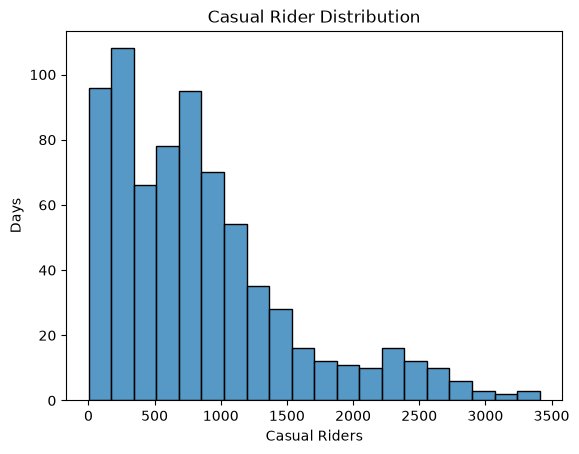

In [6]:
#2.4a
sns.histplot(bike['casual'])
plt.title("Casual Rider Distribution")
plt.xlabel("Casual Riders")
plt.ylabel("Days")
plt.show()

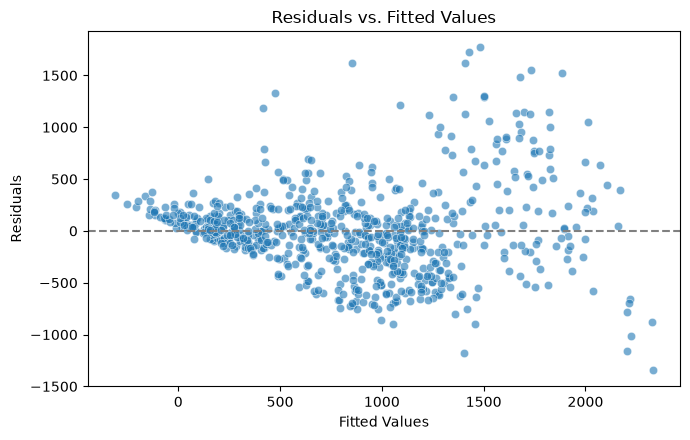

In [11]:
#2.4b
y = bike['casual']
Init = bike[['temp', 'hum', 'windspeed', 'workingday']]
X = pd.get_dummies(Init, columns = ['workingday'], drop_first=True, dtype=int)
reg = LinearRegression().fit(X, y)

yhat = reg.predict(X)
Residual = y - yhat

plt.figure(figsize=(7, 4.5))
sns.scatterplot(x=yhat, y=Residual, alpha=0.6)
plt.axhline(0, color="gray", ls="--")
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

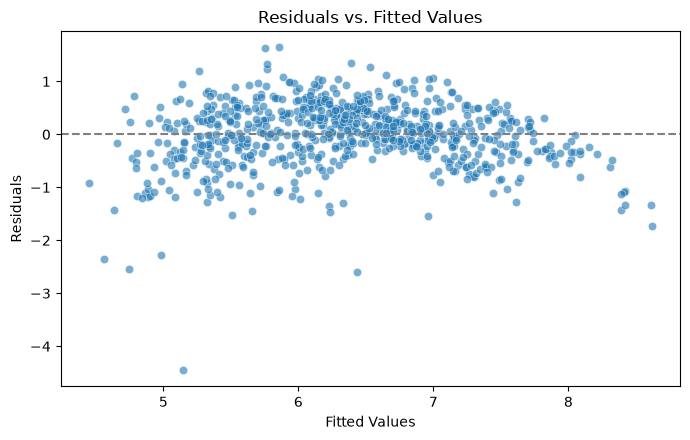

In [12]:
#2.4c
y = np.log(bike['casual'])
Init = bike[['temp', 'hum', 'windspeed', 'workingday']]
X = pd.get_dummies(Init, columns = ['workingday'], drop_first=True, dtype=int)
reg = LinearRegression().fit(X, y)

yhat = reg.predict(X)
Residual = y - yhat

plt.figure(figsize=(7, 4.5))
sns.scatterplot(x=yhat, y=Residual, alpha=0.6)
plt.axhline(0, color="gray", ls="--")
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

## 2.4

- (a) This distribution plot has a very clear right skew. 

- (b) I see that the amount of residuals increase as the casual biker count increases. This is clarifying the right skew I saw earlier.

- (c) The distribution is a lot more normal! The log() beautifully accounted for the heavy right skew. There are new residual values found on the lower end of the plot. 

- (d) Based on our readings from last week, I believe the log transformation did make sense. The right skew in the initial plot indicated that trying the log wouldn't hurt. Seeing the log transformation in plot form showed that it was the right decision because of how well the right skew was normalized. This compares to our transformation with Kepler's law in that the residuals on planet orbits had a very circular shape, so Kepler's law allowed us to normalize those data points. 

## Part 3 Note: Tejas Reddy is submitting the final project update for our group.